In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
spectrum_1 = pd.read_csv("Spectrum2s_1_noreg_gas_exp.csv")
spectrum_2 = pd.read_csv("Spectrum2s_2_noreg_gas_exp.csv")
spectrum_3 = pd.read_csv("Spectrum2s_3_noreg_gas_exp.csv")
spectrum_4 = pd.read_csv("Spectrum2s_4_noreg_gas_exp.csv")
spectrum_5 = pd.read_csv("Spectrum2s_5_noreg_gas_exp.csv")
spectrum_6 = pd.read_csv("Spectrum2s_6_noreg_gas_exp.csv")
spectrum_7 = pd.read_csv("Spectrum2s_7_noreg_gas_exp.csv")

In [4]:
spectrum_2

,Name,Flux,Error_flux
0,Hbeta,1.034795,0.049988
1,Halpha,3.868287,0.084084
2,[SII]6716,0.668542,0.025592
3,[SII]6731,0.472797,0.019999
4,HeII4687,0.005581,0.008298
5,HeI5876,0.154798,0.015587
6,[OIII]4959,0.251181,0.050397
7,[OIII]5007,0.753544,0.050397
8,[OI]6300,0.052066,0.005523
9,[OI]6364,0.017355,0.005523


In [5]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    e_1 = err_1/(flux_1*np.log(10))
    e_2 = err_2/(flux_2*np.log(10))
    print(np.sqrt((e_1)**2+(e_2)**2))
    return np.sqrt((e_1)**2+(e_2)**2)

def ratio(spectrum):
    OIII_HB = spectrum['Flux'][7]/spectrum['Flux'][0]
    NII_HA = spectrum['Flux'][11]/spectrum['Flux'][1]
    SII_HA = spectrum['Flux'][2]/spectrum['Flux'][1]
    err_OIII_HB = error_ratio(spectrum['Error_flux'][7], spectrum['Error_flux'][0], spectrum['Flux'][7], spectrum['Flux'][0])
    err_NII_HA = error_ratio(spectrum['Error_flux'][11], spectrum['Error_flux'][1], spectrum['Flux'][11], spectrum['Flux'][1])
    err_SII_HA = error_ratio(spectrum['Error_flux'][2], spectrum['Error_flux'][1], spectrum['Flux'][2], spectrum['Flux'][1]) 
    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

0.03387395407264319
0.0281556527318206
0.026984927421947295
0.03582970619919519
0.017166587471876053
0.019118029876945126
0.03114389724609325
0.014478960562850626
0.015466366328647124
0.03042154625851655
0.015914162888674154
0.017712610719889502
0.034399811049874954
0.014882695202510706
0.010476680683133446
0.043823211222683574
0.015643068520506533
0.015954868543018096
0.03928926541057274
0.016659362069146626
0.014671100153969214


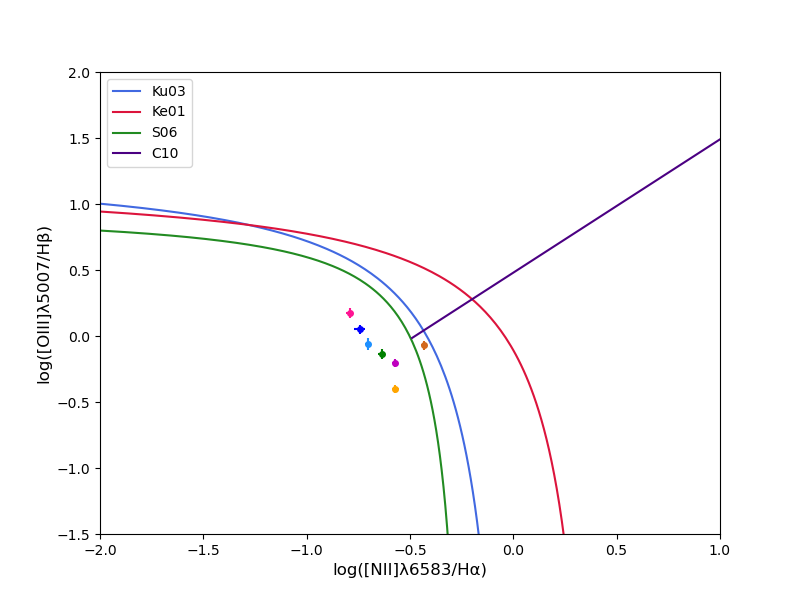

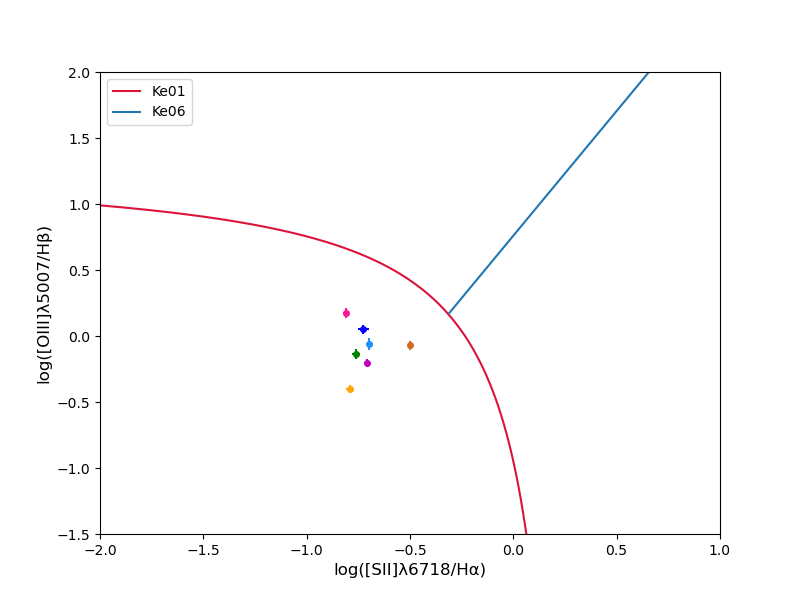

In [6]:
plt.figure(figsize=(8,6))

OIII_HB_1, NII_HA_1, SII_HA_1, err_OIII_HB_1, err_NII_HA_1, err_SII_HA_1 = ratio(spectrum_1)
OIII_HB_2, NII_HA_2, SII_HA_2, err_OIII_HB_2, err_NII_HA_2, err_SII_HA_2 = ratio(spectrum_2)
OIII_HB_3, NII_HA_3, SII_HA_3, err_OIII_HB_3, err_NII_HA_3, err_SII_HA_3 = ratio(spectrum_3)
OIII_HB_4, NII_HA_4, SII_HA_4, err_OIII_HB_4, err_NII_HA_4, err_SII_HA_4 = ratio(spectrum_4)
OIII_HB_5, NII_HA_5, SII_HA_5, err_OIII_HB_5, err_NII_HA_5, err_SII_HA_5 = ratio(spectrum_5)
OIII_HB_6, NII_HA_6, SII_HA_6, err_OIII_HB_6, err_NII_HA_6, err_SII_HA_6 = ratio(spectrum_6)
OIII_HB_7, NII_HA_7, SII_HA_7, err_OIII_HB_7, err_NII_HA_7, err_SII_HA_7 = ratio(spectrum_7)

plt.errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_5), y =np.log10(OIII_HB_5), xerr = err_NII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_6), y =np.log10(OIII_HB_6), xerr = err_NII_HA_6, yerr = err_OIII_HB_6, color = 'dodgerblue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_7), y =np.log10(OIII_HB_7), xerr = err_NII_HA_7, yerr = err_OIII_HB_7, color = 'deeppink', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
plt.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue', zorder = 1)
plt.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson', zorder = 1)
plt.plot(x2, S06(x2), label = 'S06', color = 'forestgreen', zorder = 1)
plt.plot(x3, C10(x3), label = 'C10', color = 'indigo', zorder = 1)
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_2s', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_4), y = np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_5), y =np.log10(OIII_HB_5), xerr = err_SII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_6), y =np.log10(OIII_HB_6), xerr = err_SII_HA_6, yerr = err_OIII_HB_6, color = 'dodgerblue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_7), y =np.log10(OIII_HB_7), xerr = err_SII_HA_7, yerr = err_OIII_HB_7, color = 'deeppink', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson', zorder = 1)
plt.plot(x1, Ke06(x1), label = 'Ke06', zorder = 1)

plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_2s', bbox_inches='tight')

## BPT con correzioni

In [7]:
areas_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/Contaminations/Areas_OIII_2s.csv",
                        index_col = 0)
areas_NII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/Contaminations/Areas_NII_2s.csv",
                        index_col = 0)
areas_SII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/Contaminations/Areas_SII_2s.csv",
                        index_col = 0)
areas_Halpha = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/Contaminations/Areas_Halpha_2s.csv",
                        index_col = 0)
areas_Hbeta = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/Contaminations/Areas_Hbeta_2s.csv",
                        index_col = 0)

In [8]:
def true_flux(spectrum1, spectrum2, spectrum3, spectrum4, spectrum5, spectrum6, spectrum7, area, e_1, e_2, e_3, e_4, e_5, e_6, e_7):
    riga_1 = spectrum1*area['Peak 1'].iloc[0]/100
    err_1 = e_1 * area['Peak 1'].iloc[0]/100
    
    riga_2 = spectrum2 * area['Peak 2'].iloc[1]/100
    err_2 = e_2 * area['Peak 2'].iloc[1]/100
    
    riga_3 = spectrum3 * area['Peak 3'].iloc[2]/100
    err_3 = e_3 * area['Peak 3'].iloc[2]/100
    
    riga_4 = spectrum4*area['Peak 4'].iloc[3]/100
    err_4 = e_4 * area['Peak 4'].iloc[3]/100
    
    riga_5 = spectrum5 * area['Peak 5'].iloc[4]/100
    err_5 = e_5 * area['Peak 5'].iloc[4]/100
    
    riga_6 = spectrum6 * area['Peak 6'].iloc[5]/100
    err_6 = e_6 * area['Peak 6'].iloc[5]/100
    
    riga_7 = spectrum7 * area['Peak 7'].iloc[6]/100
    err_7 = e_7 * area['Peak 7'].iloc[6]/100
    return riga_1, riga_2, riga_3, riga_4, riga_5, riga_6, riga_7, err_1, err_2, err_3, err_4, err_5, err_6, err_7

def ratio_true(OIII, HB, HA, NII, SII, err_OIII, err_HB, err_HA, err_NII, err_SII):
    OIII_HB_true = OIII/HB
    NII_HA_true = NII/HA
    SII_HA_true = SII/HA
    err_OIII_HB_true = error_ratio(err_OIII, err_HB, OIII, HB)
    err_NII_HA_true = error_ratio(err_NII, err_HA, NII, HA)
    err_SII_HA_true = error_ratio(err_SII, err_HA, SII, HA)
    return OIII_HB_true, NII_HA_true, SII_HA_true, err_OIII_HB_true, err_SII_HA_true, err_NII_HA_true

In [9]:
OIII_1, OIII_2, OIII_3, OIII_4, OIII_5, OIII_6, OIII_7, err_OIII_1, err_OIII_2, err_OIII_3, err_OIII_4, err_OIII_5, err_OIII_6, err_OIII_7 = true_flux(spectrum_1['Flux'][7], spectrum_2['Flux'][7], 
                                                                                           spectrum_3['Flux'][7], spectrum_4['Flux'][7], spectrum_5['Flux'][7],
                                                                                           spectrum_6['Flux'][7], spectrum_7['Flux'][7], areas_OIII,
                                                                                          spectrum_1['Error_flux'][7], spectrum_2['Error_flux'][7], 
                                                                                           spectrum_3['Error_flux'][7], spectrum_4['Error_flux'][7], 
                                                                                            spectrum_5['Error_flux'][7], spectrum_6['Error_flux'][7], spectrum_7['Error_flux'][7])
HB_1, HB_2, HB_3, HB_4, HB_5, HB_6, HB_7, err_HB_1, err_HB_2, err_HB_3, err_HB_4, err_HB_5, err_HB_6, err_HB_7 = true_flux(spectrum_1['Flux'][0], spectrum_2['Flux'][0], 
                                                    spectrum_3['Flux'][0], spectrum_4['Flux'][0], spectrum_5['Flux'][0],
                                                    spectrum_6['Flux'][0], spectrum_7['Flux'][0], areas_Hbeta,
                                                    spectrum_1['Error_flux'][0], spectrum_2['Error_flux'][0], 
                                                    spectrum_3['Error_flux'][0], spectrum_4['Error_flux'][0], 
                                                    spectrum_5['Error_flux'][0], spectrum_6['Error_flux'][0], spectrum_7['Error_flux'][0])
HA_1, HA_2, HA_3, HA_4, HA_5, HA_6, HA_7, err_HA_1, err_HA_2, err_HA_3, err_HA_4, err_HA_5, err_HA_6, err_HA_7 = true_flux(spectrum_1['Flux'][1], spectrum_2['Flux'][1], 
                                                    spectrum_3['Flux'][1], spectrum_4['Flux'][1], spectrum_5['Flux'][1],
                                                    spectrum_6['Flux'][1], spectrum_7['Flux'][1], areas_Halpha,
                                                    spectrum_1['Error_flux'][1], spectrum_2['Error_flux'][1], 
                                                    spectrum_3['Error_flux'][1], spectrum_4['Error_flux'][1], 
                                                    spectrum_5['Error_flux'][1], spectrum_6['Error_flux'][1], spectrum_7['Error_flux'][1])
NII_1, NII_2, NII_3, NII_4, NII_5, NII_6, NII_7, err_NII_1, err_NII_2, err_NII_3, err_NII_4, err_NII_5, err_NII_6, err_NII_7 = true_flux(spectrum_1['Flux'][11], spectrum_2['Flux'][11], 
                                                    spectrum_3['Flux'][11], spectrum_4['Flux'][11], spectrum_5['Flux'][11],
                                                    spectrum_6['Flux'][11], spectrum_7['Flux'][11], areas_NII,
                                                    spectrum_1['Error_flux'][11], spectrum_2['Error_flux'][11], 
                                                    spectrum_3['Error_flux'][11], spectrum_4['Error_flux'][11], 
                                                    spectrum_5['Error_flux'][11], spectrum_6['Error_flux'][11], spectrum_7['Error_flux'][11])
SII_1, SII_2, SII_3, SII_4, SII_5, SII_6, SII_7, err_SII_1, err_SII_2, err_SII_3, err_SII_4, err_SII_5, err_SII_6, err_SII_7 = true_flux(spectrum_1['Flux'][2], spectrum_2['Flux'][2], 
                                                    spectrum_3['Flux'][2], spectrum_4['Flux'][2], spectrum_5['Flux'][2],
                                                    spectrum_6['Flux'][2], spectrum_7['Flux'][2], areas_SII,
                                                    spectrum_1['Error_flux'][2], spectrum_2['Error_flux'][2], 
                                                    spectrum_3['Error_flux'][2], spectrum_4['Error_flux'][2], 
                                                    spectrum_5['Error_flux'][2], spectrum_6['Error_flux'][2], spectrum_7['Error_flux'][2])

In [10]:
areas_SII

,Peak 1,Peak 2,Peak 3,Peak 4,Peak 5,Peak 6,Peak 7
Blue,68.563,0.301,0.148,0.031,0.008,0.003,0.001
Green,0.000,34.586,6.734,0.001,0.000,0.000,0.000
Magenta,0.000,0.660,17.602,0.000,0.000,0.000,0.000
Orange,31.437,63.820,73.695,94.026,43.110,29.729,11.355
Chocolate,0.000,0.634,1.822,5.943,56.847,26.582,3.692
Purple,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Deeppink,0.000,0.000,0.000,0.000,0.034,43.686,84.952


In [11]:
spectrum_6['Flux'][2]

0.9633690215284514

In [12]:
SII_6

0.0

0.0338739540726432
0.028155652731820607
0.026984927421947302
0.03582970619919519
0.017166587471876053
0.019118029876945126
0.031143897246093254
0.014478960562850626
0.015466366328647124
0.030421546258516556
0.015914162888674154
0.017712610719889506
0.034399811049874954
0.014882695202510706
0.010476680683133446
0.04382321122268358
0.015643068520506533
nan
0.039289265410572746
0.016659362069146623
0.014671100153969212


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20432\2548819968.py:30: RuntimeWarning: invalid value encountered in scalar divide
  e_1 = err_1/(flux_1*np.log(10))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20432\277870643.py:48: RuntimeWarning: divide by zero encountered in log10
  plt.errorbar(x = np.log10(SII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_SII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')


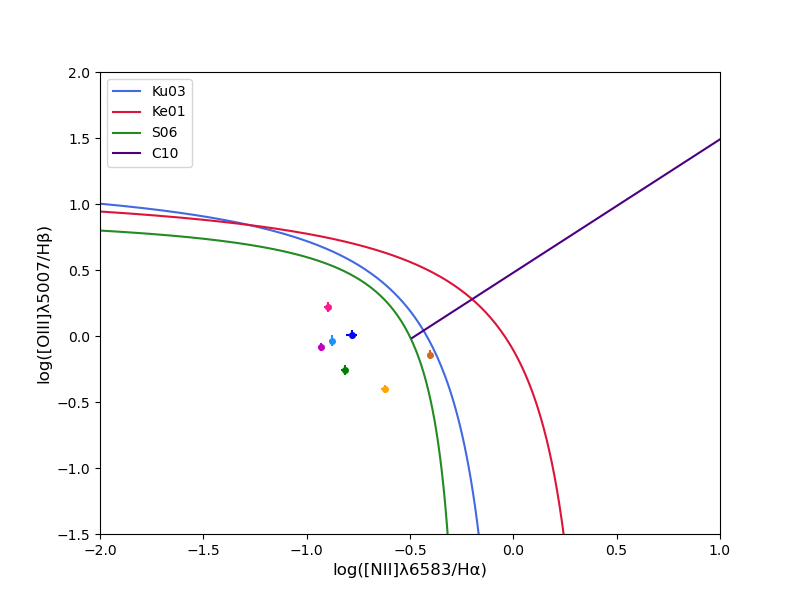

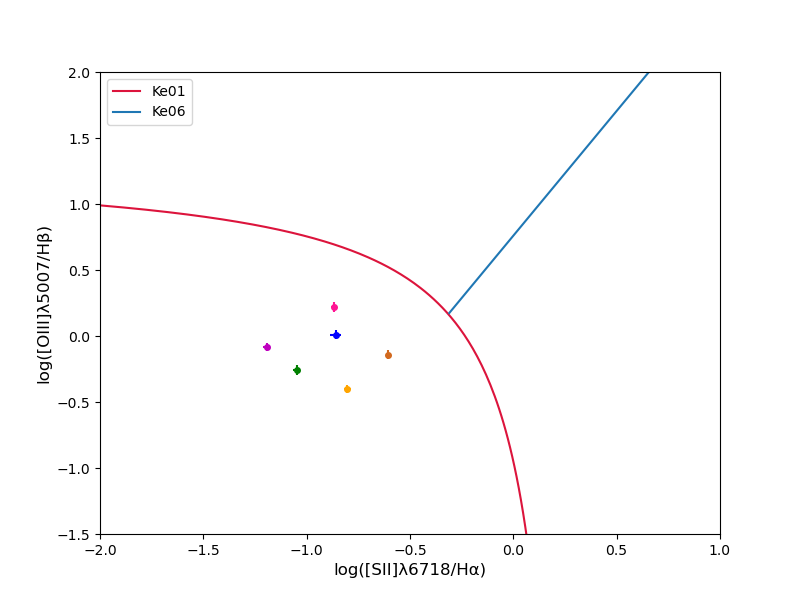

In [13]:
plt.figure(figsize=(8,6))

OIII_HB_1_true, NII_HA_1_true, SII_HA_1_true, err_OIII_HB_1_true, err_SII_HA_1_true, err_NII_HA_1_true = ratio_true(OIII_1, HB_1, HA_1, NII_1, 
                                                                                       SII_1, err_OIII_1, err_HB_1, err_HA_1, err_NII_1, err_SII_1)
OIII_HB_2_true, NII_HA_2_true, SII_HA_2_true, err_OIII_HB_2_true, err_SII_HA_2_true, err_NII_HA_2_true = ratio_true(OIII_2, HB_2, HA_2, NII_2, 
                                                                                       SII_2, err_OIII_2, err_HB_2, err_HA_2, err_NII_2, err_SII_2)
OIII_HB_3_true, NII_HA_3_true, SII_HA_3_true, err_OIII_HB_3_true, err_SII_HA_3_true, err_NII_HA_3_true = ratio_true(OIII_3, HB_3, HA_3, NII_3, 
                                                                                       SII_3, err_OIII_3, err_HB_3, err_HA_3, err_NII_3, err_SII_3)
OIII_HB_4_true, NII_HA_4_true, SII_HA_4_true, err_OIII_HB_4_true, err_SII_HA_4_true, err_NII_HA_4_true = ratio_true(OIII_4, HB_4, HA_4, NII_4, 
                                                                                       SII_4, err_OIII_4, err_HB_4, err_HA_4, err_NII_4, err_SII_4)
OIII_HB_5_true, NII_HA_5_true, SII_HA_5_true, err_OIII_HB_5_true, err_SII_HA_5_true, err_NII_HA_5_true = ratio_true(OIII_5, HB_5, HA_5, NII_5, 
                                                                                       SII_5, err_OIII_5, err_HB_5, err_HA_5, err_NII_5, err_SII_5)
OIII_HB_6_true, NII_HA_6_true, SII_HA_6_true, err_OIII_HB_6_true, err_SII_HA_6_true, err_NII_HA_6_true = ratio_true(OIII_6, HB_6, HA_6, NII_6, 
                                                                                       SII_6, err_OIII_6, err_HB_6, err_HA_6, err_NII_6, err_SII_6)
OIII_HB_7_true, NII_HA_7_true, SII_HA_7_true, err_OIII_HB_7_true, err_SII_HA_7_true, err_NII_HA_7_true = ratio_true(OIII_7, HB_7, HA_7, NII_7, 
                                                                                       SII_7, err_OIII_7, err_HB_7, err_HA_7, err_NII_7, err_SII_7)

plt.errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_NII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_NII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_7_true), y = np.log10(OIII_HB_7_true), xerr = err_NII_HA_7_true, yerr = err_OIII_HB_7_true, color = 'deeppink', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
plt.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue', zorder = 1)
plt.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson', zorder = 1)
plt.plot(x2, S06(x2), label = 'S06', color = 'forestgreen', zorder = 1)
plt.plot(x3, C10(x3), label = 'C10', color = 'indigo', zorder = 1)
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_2s_true', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_SII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_SII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_7_true), y = np.log10(OIII_HB_7_true), xerr = err_SII_HA_7_true, yerr = err_OIII_HB_7_true, color = 'deeppink', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson', zorder = 1)
plt.plot(x1, Ke06(x1), label = 'Ke06', zorder = 1)

plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_2s_true', bbox_inches='tight')

## NON è stato possibile fare la correzione per SII del picco 6 perchè l'area è piccolissima dal fit 

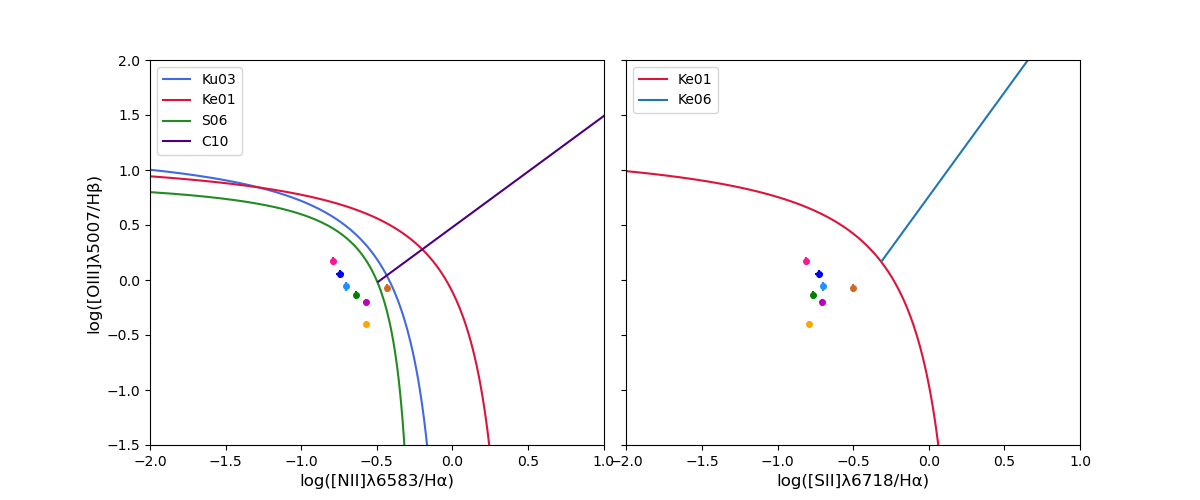

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_5), y =np.log10(OIII_HB_5), xerr = err_NII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_6), y =np.log10(OIII_HB_6), xerr = err_NII_HA_6, yerr = err_OIII_HB_6, color = 'dodgerblue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_7), y =np.log10(OIII_HB_7), xerr = err_NII_HA_7, yerr = err_OIII_HB_7, color = 'deeppink', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue', zorder = 1)
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson', zorder = 1)
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen', zorder = 1)
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo', zorder = 1)
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_4), y = np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_5), y =np.log10(OIII_HB_5), xerr = err_SII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_6), y =np.log10(OIII_HB_6), xerr = err_SII_HA_6, yerr = err_OIII_HB_6, color = 'dodgerblue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_7), y =np.log10(OIII_HB_7), xerr = err_SII_HA_7, yerr = err_OIII_HB_7, color = 'deeppink', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson', zorder = 1)
ax[1].plot(x1, Ke06(x1), label = 'Ke06', zorder = 1)
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_2s_both.png', bbox_inches='tight')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20432\4187389316.py:30: RuntimeWarning: divide by zero encountered in log10
  ax[1].errorbar(x = np.log10(SII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_SII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')


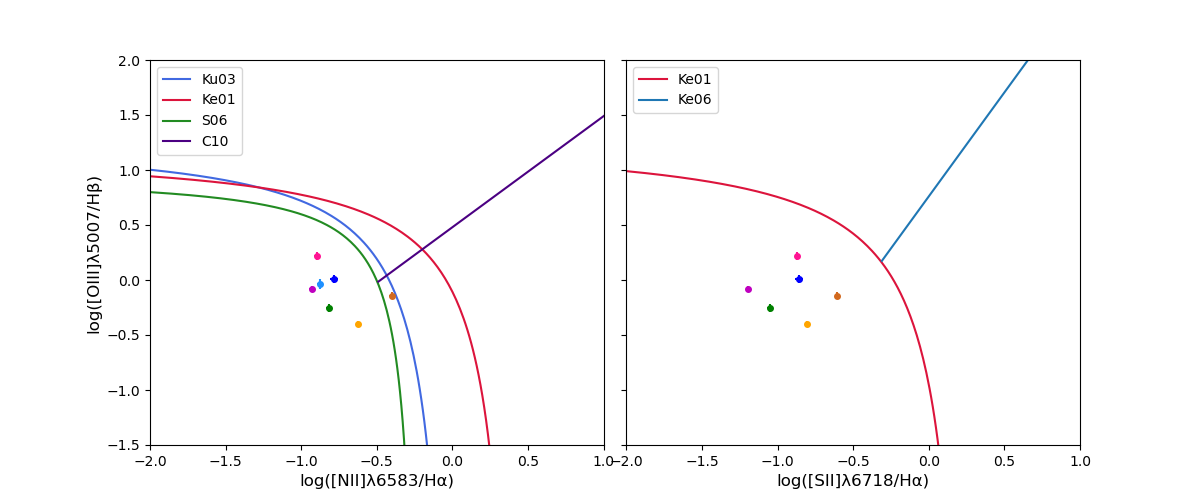

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_NII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_NII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_7_true), y = np.log10(OIII_HB_7_true), xerr = err_NII_HA_7_true, yerr = err_OIII_HB_7_true, color = 'deeppink', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue', zorder = 1)
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson', zorder = 1)
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen', zorder = 1)
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo', zorder = 1)
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_SII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_SII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_7_true), y = np.log10(OIII_HB_7_true), xerr = err_SII_HA_7_true, yerr = err_OIII_HB_7_true, color = 'deeppink', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson', zorder = 1)
ax[1].plot(x1, Ke06(x1), label = 'Ke06', zorder = 1)
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_2s_both_true.png', bbox_inches='tight')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20432\817648430.py:45: RuntimeWarning: divide by zero encountered in log10
  ax[1].errorbar(x = np.log10(SII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_SII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')


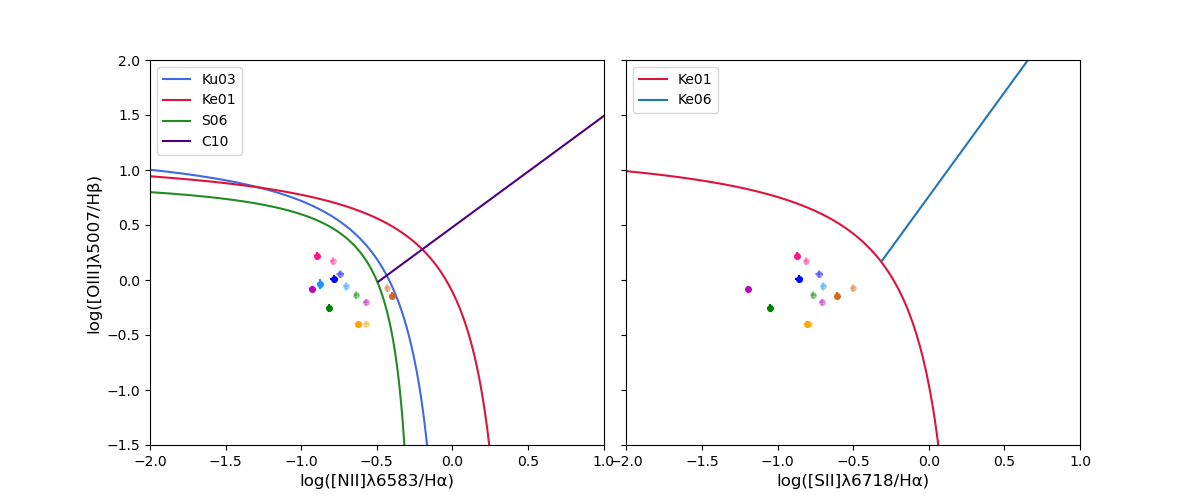

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_5), y =np.log10(OIII_HB_5), xerr = err_NII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_6), y =np.log10(OIII_HB_6), xerr = err_NII_HA_6, yerr = err_OIII_HB_6, color = 'dodgerblue', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_7), y =np.log10(OIII_HB_7), xerr = err_NII_HA_7, yerr = err_OIII_HB_7, color = 'deeppink', markersize = 4, marker = 'o', alpha = 0.3)

ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_NII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_NII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_7_true), y = np.log10(OIII_HB_7_true), xerr = err_NII_HA_7_true, yerr = err_OIII_HB_7_true, color = 'deeppink', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue', zorder = 1)
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson', zorder = 1)
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen', zorder = 1)
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo', zorder = 1)
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_4), y = np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_5), y =np.log10(OIII_HB_5), xerr = err_SII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_6), y =np.log10(OIII_HB_6), xerr = err_SII_HA_6, yerr = err_OIII_HB_6, color = 'dodgerblue', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_7), y =np.log10(OIII_HB_7), xerr = err_SII_HA_7, yerr = err_OIII_HB_7, color = 'deeppink', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_SII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_SII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_7_true), y = np.log10(OIII_HB_7_true), xerr = err_SII_HA_7_true, yerr = err_OIII_HB_7_true, color = 'deeppink', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson', zorder = 1)
ax[1].plot(x1, Ke06(x1), label = 'Ke06', zorder = 1)
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_2s_motion.png', bbox_inches='tight')

In [17]:
OIII_1

0.4345004661815953

In [18]:
err_OIII_1

0.028781973752886693

In [19]:
error_ratio(spectrum_4['Error_flux'][8], spectrum_4['Error_flux'][1], spectrum_4['Flux'][8], spectrum_4['Flux'][1])

0.036331497344269915


0.036331497344269915

In [20]:
error_ratio(err_OIII_4, err_HB_4, OIII_4, HB_4)

0.030421546258516556


0.030421546258516556